# Student Placement Prediction System

## End-to-End Machine Learning Project with Streamlit Deployment

**Name:** Akshit Singh Bundela

**Internship:** Grant Thornton Bharat LLP

**Domain:** Business Analytics

**Assignment:** Python Machine Learning Assignment

---

# Phase 1 – Business Understanding

## 1. Problem Statement

Educational institutions receive hundreds or even thousands of students every year. During placement season, it becomes difficult for placement officers to manually identify which students are likely to be placed because placement depends on multiple factors such as CGPA, internships, projects, coding skills, communication skills, aptitude scores, certifications, and academic backlogs.

A manual evaluation process is time-consuming and may not always provide consistent results. Therefore, there is a need for an intelligent system that can analyze student data and predict placement outcomes using Machine Learning.

This project develops a Student Placement Prediction System that predicts whether a student is likely to be placed based on academic performance and skill-related attributes.

## 2. Objective

The primary objective of this project is to develop a Machine Learning model that predicts whether a student is likely to be placed based on academic performance and skill-related factors.

The project also aims to:

- Predict student placement status accurately.
- Help placement officers identify placement-ready students.
- Assist students in improving important skills before campus placements.
- Support data-driven decision-making in educational institutions.

## 3. Business Impact

This project provides value to multiple stakeholders.

### Benefits for Colleges
- Identify students who require additional training.
- Improve overall placement performance.
- Support placement planning using data.

### Benefits for Students
- Understand strengths and weaknesses.
- Improve skills before placement drives.
- Increase placement readiness.

### Benefits for Recruiters
- Quickly identify students with strong placement potential.
- Reduce manual screening effort.
- Improve hiring efficiency.

## 4. Use Case

The Student Placement Prediction System can be integrated into a college placement portal.

Students enter information such as Age, Degree, Branch, CGPA, Internships, Projects, Coding Skills, Communication Skills, Aptitude Test Score, Certifications, and Backlogs.

The Machine Learning model analyzes this information and predicts whether the student is likely to be placed. This helps students prepare better and assists placement officers in monitoring placement readiness.

## 5. Expected Outcome

The expected outcome of this project is a Machine Learning model capable of accurately predicting student placement status.

The final system will:
- Predict placement status with good accuracy.
- Support students in improving employability.
- Assist colleges in placement planning.
- Provide a user-friendly Streamlit application for real-time predictions.

In [1]:
### Section 1  Import Libraries

In [2]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

###  Section 2  Load Dataset

In [82]:
# Load Dataset

df = pd.read_excel("C:/Users/My/Downloads/datasheet_assignmet 3.xlsx")
df = df.drop(columns=["Unnamed: 0"])

### Section 3  Data Understanding

In [83]:
# Display first 5 rows

df.head()

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [86]:
# Number of rows and columns

df.shape

(45000, 14)

In [84]:
# Show all column names

df.columns

Index(['Age', 'Gender', 'Degree', 'Branch', 'CGPA', 'Internships', 'Projects',
       'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score',
       'Soft_Skills_Rating', 'Certifications', 'Backlogs', 'Placement_Status'],
      dtype='object')

In [85]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   45000 non-null  int64  
 1   Gender                45000 non-null  object 
 2   Degree                45000 non-null  object 
 3   Branch                45000 non-null  object 
 4   CGPA                  45000 non-null  float64
 5   Internships           45000 non-null  int64  
 6   Projects              45000 non-null  int64  
 7   Coding_Skills         45000 non-null  int64  
 8   Communication_Skills  45000 non-null  int64  
 9   Aptitude_Test_Score   45000 non-null  int64  
 10  Soft_Skills_Rating    45000 non-null  int64  
 11  Certifications        45000 non-null  int64  
 12  Backlogs              45000 non-null  int64  
 13  Placement_Status      45000 non-null  object 
dtypes: float64(1), int64(9), object(4)
memory usage: 4.8+ MB


In [8]:
# Summary of numerical columns

df.describe()

,Unnamed: 0,Age,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
count,0.0,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,NaN,20.999333,7.002290,0.774089,3.734222,5.691800,5.501644,69.385356,5.501644,1.800956,0.888133
std,NaN,1.995071,0.993855,0.844750,0.923738,1.994674,1.515374,13.909710,1.238722,0.650104,0.970954
min,NaN,18.000000,4.500000,0.000000,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000
25%,NaN,19.000000,6.320000,0.000000,3.000000,4.000000,4.000000,60.000000,5.000000,1.000000,0.000000
50%,NaN,21.000000,7.000000,1.000000,4.000000,6.000000,6.000000,69.000000,5.000000,2.000000,1.000000
75%,NaN,23.000000,7.670000,1.000000,4.000000,7.000000,7.000000,79.000000,6.000000,2.000000,2.000000
max,NaN,24.000000,9.800000,3.000000,6.000000,10.000000,10.000000,100.000000,10.000000,3.000000,3.000000


In [9]:
# Missing Values

df.isnull().sum()

Unnamed: 0              45000
Age                         0
Gender                      0
Degree                      0
Branch                      0
CGPA                        0
Internships                 0
Projects                    0
Coding_Skills               0
Communication_Skills        0
Aptitude_Test_Score         0
Soft_Skills_Rating          0
Certifications              0
Backlogs                    0
Placement_Status            0
dtype: int64

In [10]:
# Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [11]:
# Count of Placement Status

df["Placement_Status"].value_counts()

Placement_Status
Not Placed    28688
Placed        16312
Name: count, dtype: int64

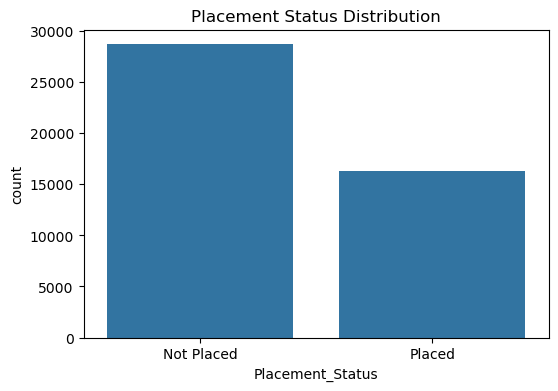

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="Placement_Status", data=df)
plt.title("Placement Status Distribution")
plt.show()

### Exploratory Data Analysis (EDA)

In [13]:
# Check data types

df.dtypes

Unnamed: 0              float64
Age                       int64
Gender                   object
Degree                   object
Branch                   object
CGPA                    float64
Internships               int64
Projects                  int64
Coding_Skills             int64
Communication_Skills      int64
Aptitude_Test_Score       int64
Soft_Skills_Rating        int64
Certifications            int64
Backlogs                  int64
Placement_Status         object
dtype: object

In [14]:
# Check unique values in each column

for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())
    


Unnamed: 0
[nan]

Age
[22 20 21 19 24 23 18]

Gender
['Female' 'Male']

Degree
['B.Tech' 'BCA' 'MCA' 'B.Sc']

Branch
['ECE' 'ME' 'Civil' 'CSE' 'IT']

CGPA
[6.29 6.05 7.22 7.78 7.63 7.99 7.5  8.   6.24 7.08 5.42 7.48 7.58 6.74
 6.11 6.79 7.41 5.97 6.69 7.95 7.3  7.02 7.29 7.69 8.47 7.97 6.89 7.49
 7.27 8.17 7.83 6.9  5.22 6.09 6.35 5.63 7.67 5.52 6.1  6.4  8.18 6.96
 5.37 7.72 6.04 8.64 8.19 8.03 9.04 7.61 8.09 7.04 6.52 6.31 6.59 5.92
 5.85 9.26 8.21 7.06 7.56 5.75 5.8  6.12 5.76 8.68 7.59 9.11 6.5  7.38
 6.54 6.7  9.16 9.15 6.3  6.32 7.77 8.07 7.01 5.07 6.47 8.8  5.88 5.35
 6.38 6.75 7.68 6.21 7.12 4.87 6.97 8.4  6.99 8.04 4.5  8.15 7.37 6.62
 6.78 6.71 7.62 5.81 7.14 8.46 6.19 7.89 8.5  8.63 6.67 7.03 7.7  6.87
 5.47 5.66 8.44 6.15 5.54 8.29 6.55 7.17 6.06 8.39 6.41 7.26 6.57 7.44
 7.55 8.35 6.84 4.95 7.79 4.58 6.27 6.43 7.16 6.91 7.84 7.65 8.92 7.4
 6.6  5.94 7.87 8.41 5.14 5.38 5.65 6.77 7.25 6.61 7.43 8.08 5.86 7.11
 7.64 7.05 7.96 4.93 9.   9.3  8.01 8.11 8.86 7.85 6.53 8.06 6.9

In [15]:
# Number of unique values

df.nunique()

Unnamed: 0                0
Age                       7
Gender                    2
Degree                    4
Branch                    5
CGPA                    531
Internships               4
Projects                  6
Coding_Skills            10
Communication_Skills     10
Aptitude_Test_Score      66
Soft_Skills_Rating       10
Certifications            4
Backlogs                  4
Placement_Status          2
dtype: int64

### Section 4  Exploratory Data Analysis (EDA)

In [16]:
numerical_columns = [
    'Age',
    'CGPA',
    'Internships',
    'Projects',
    'Coding_Skills',
    'Communication_Skills',
    'Aptitude_Test_Score',
    'Soft_Skills_Rating',
    'Certifications',
    'Backlogs'
]

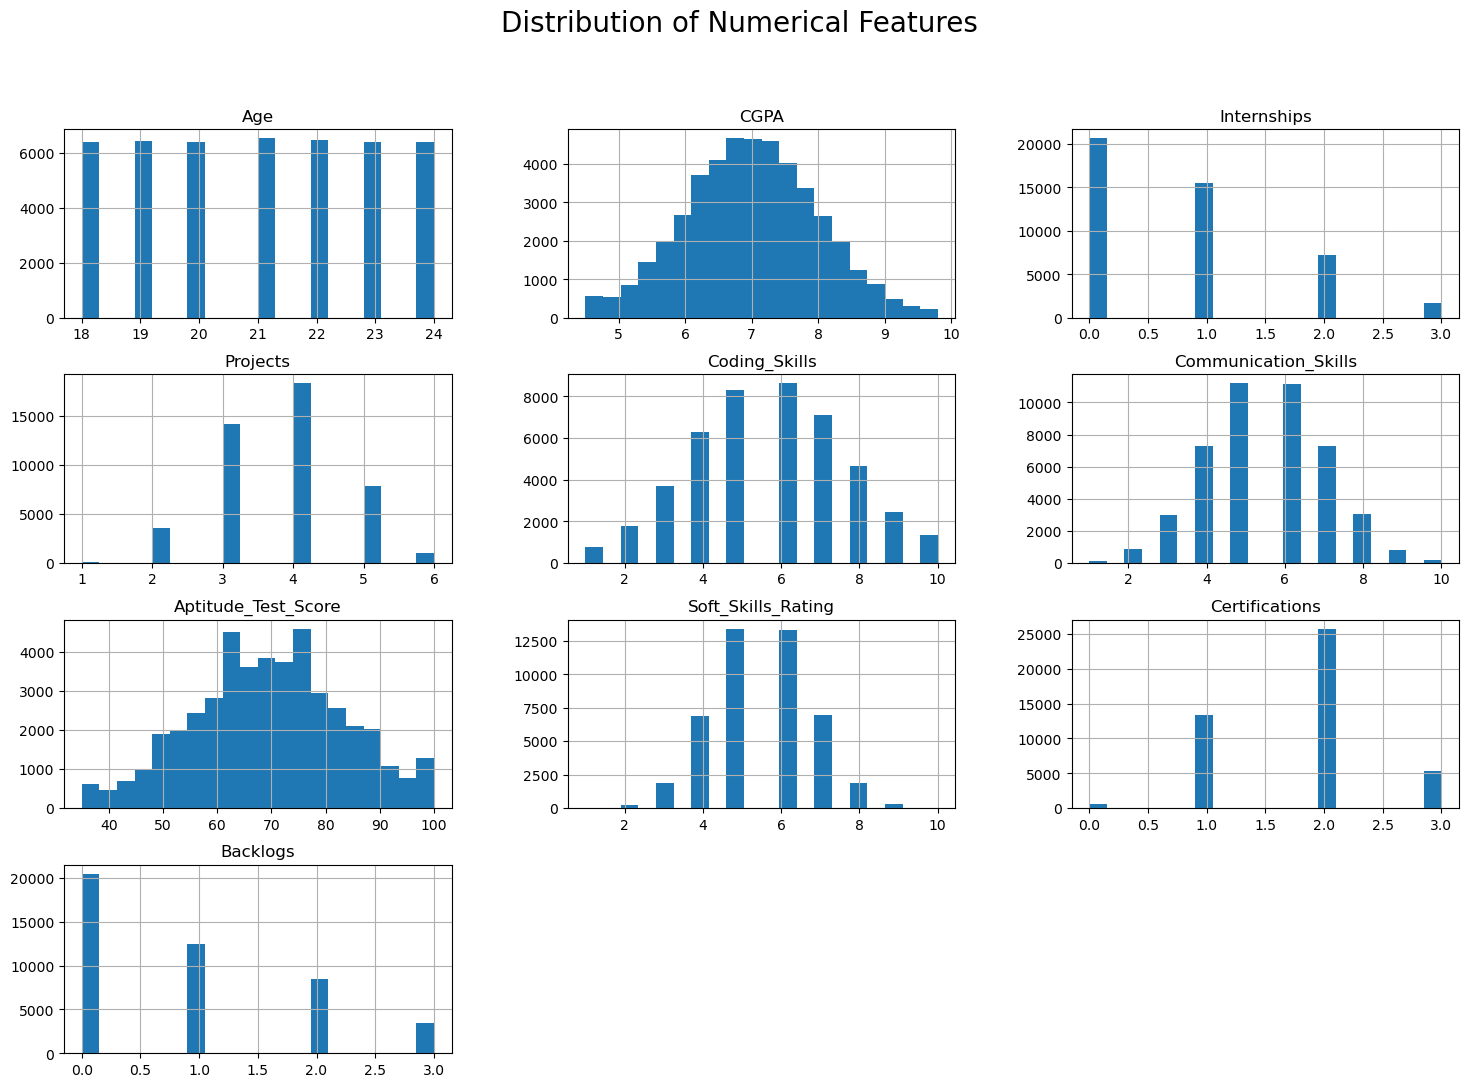

In [17]:
df[numerical_columns].hist(figsize=(18,12), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=20)

plt.show()

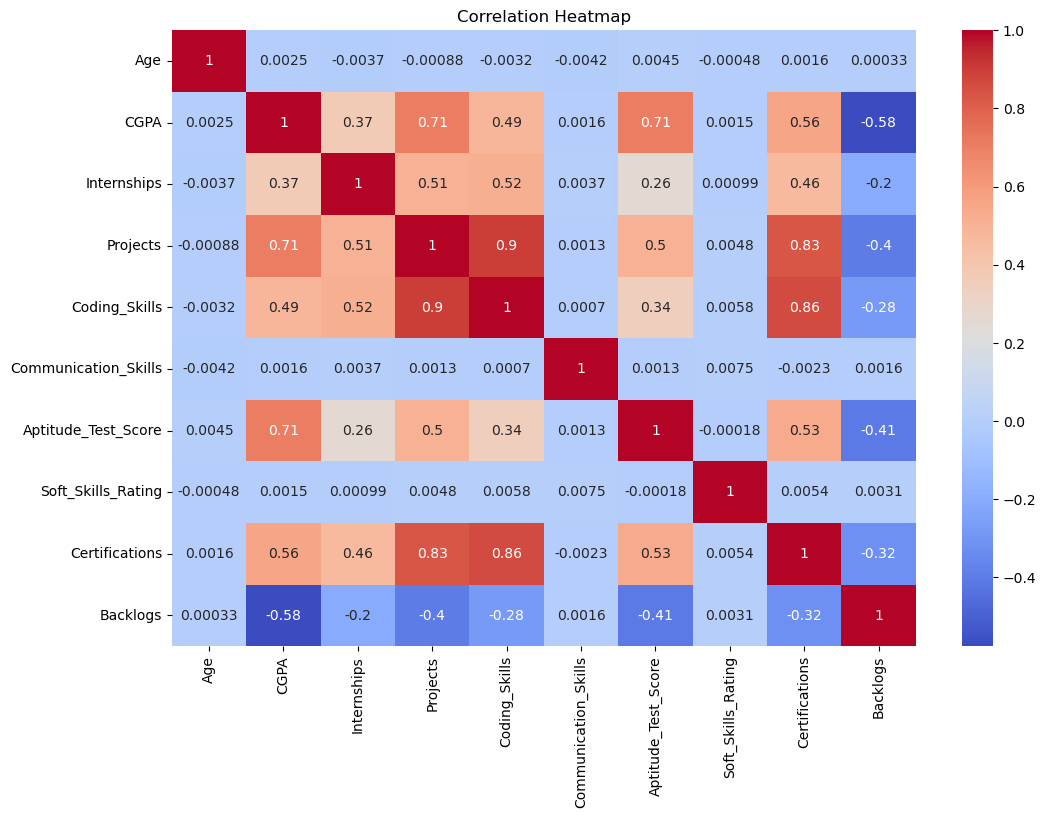

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

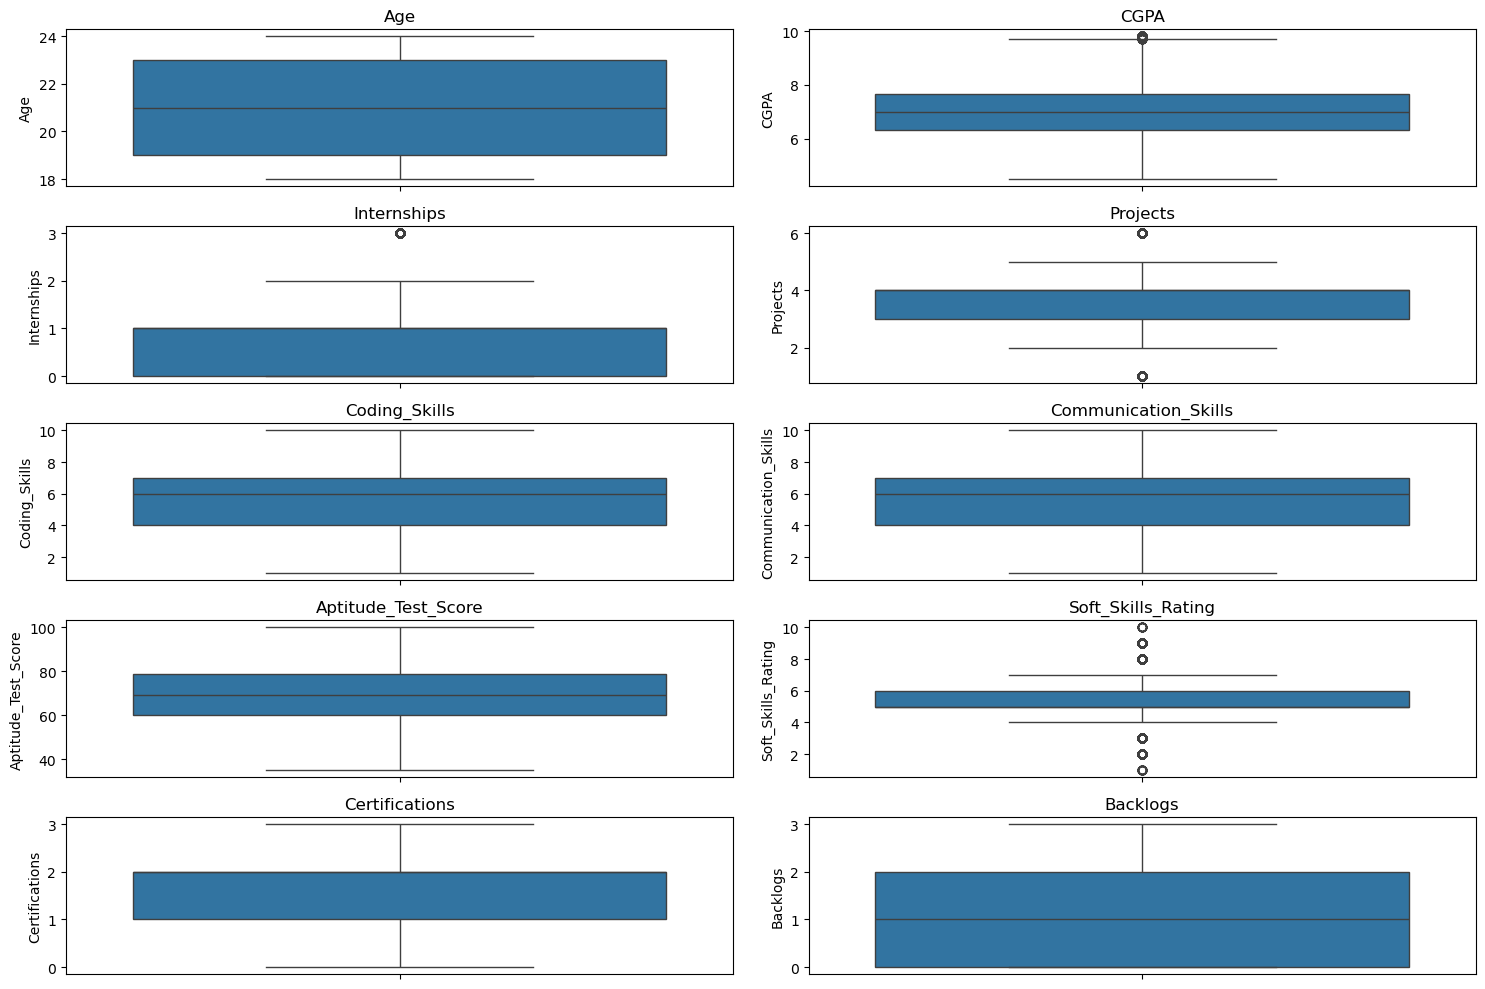

In [19]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_columns):
    plt.subplot(5,2,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()

plt.show()

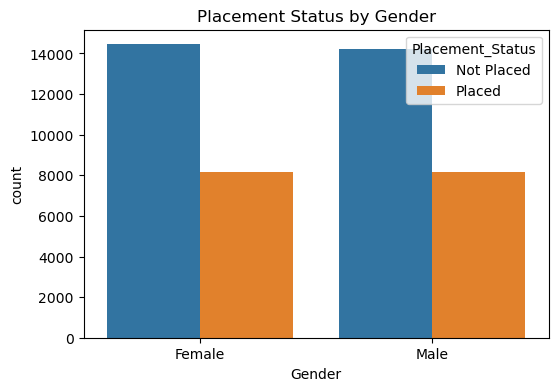

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", hue="Placement_Status", data=df)

plt.title("Placement Status by Gender")

plt.show()

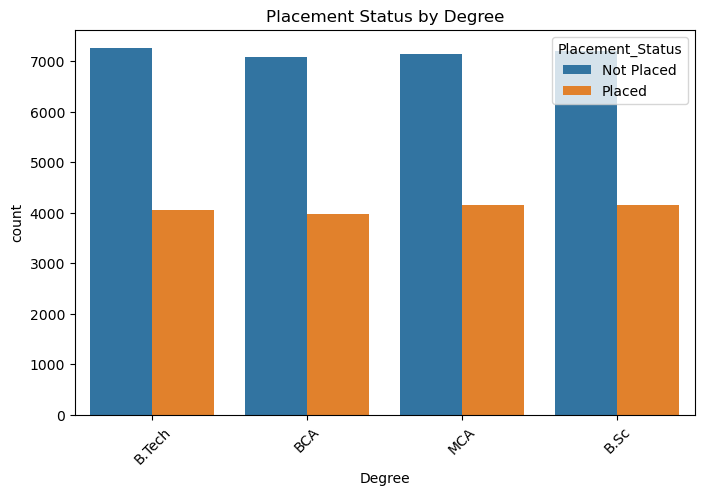

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x="Degree", hue="Placement_Status", data=df)

plt.xticks(rotation=45)

plt.title("Placement Status by Degree")

plt.show()

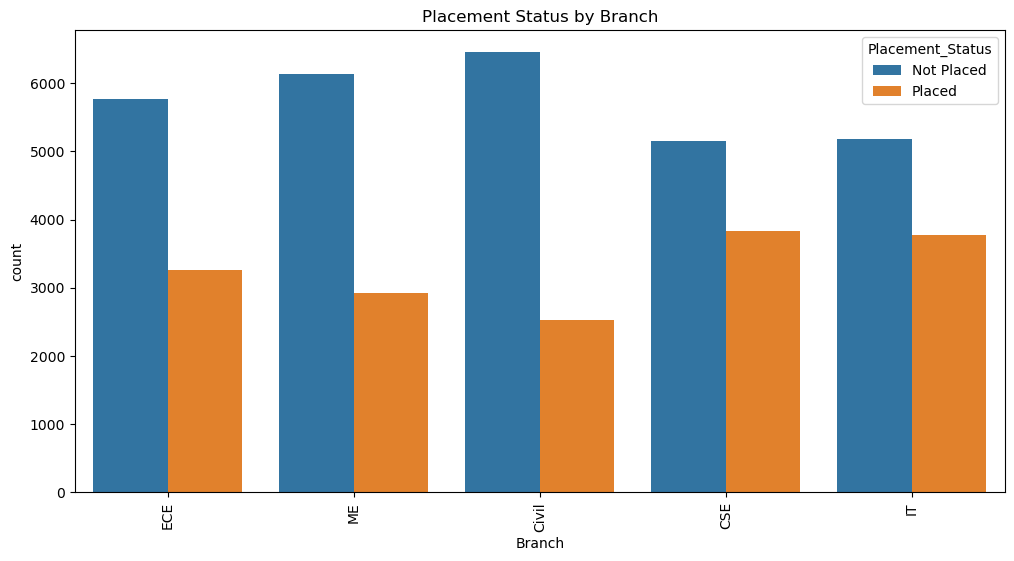

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(x="Branch", hue="Placement_Status", data=df)

plt.xticks(rotation=90)

plt.title("Placement Status by Branch")

plt.show()

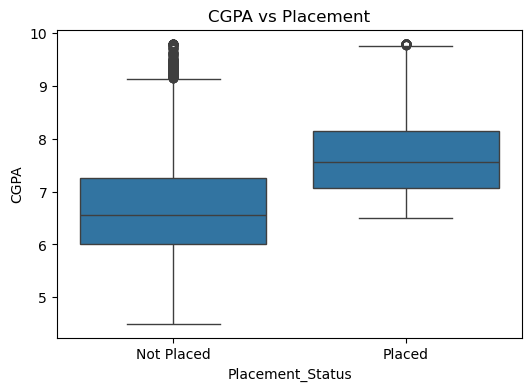

In [23]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Placement_Status", y="CGPA", data=df)

plt.title("CGPA vs Placement")

plt.show()

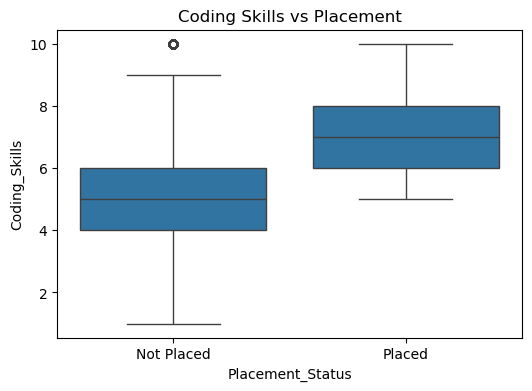

In [24]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Placement_Status", y="Coding_Skills", data=df)

plt.title("Coding Skills vs Placement")

plt.show()

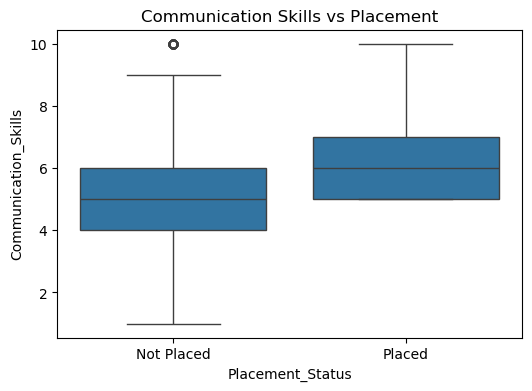

In [25]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Placement_Status", y="Communication_Skills", data=df)

plt.title("Communication Skills vs Placement")

plt.show()

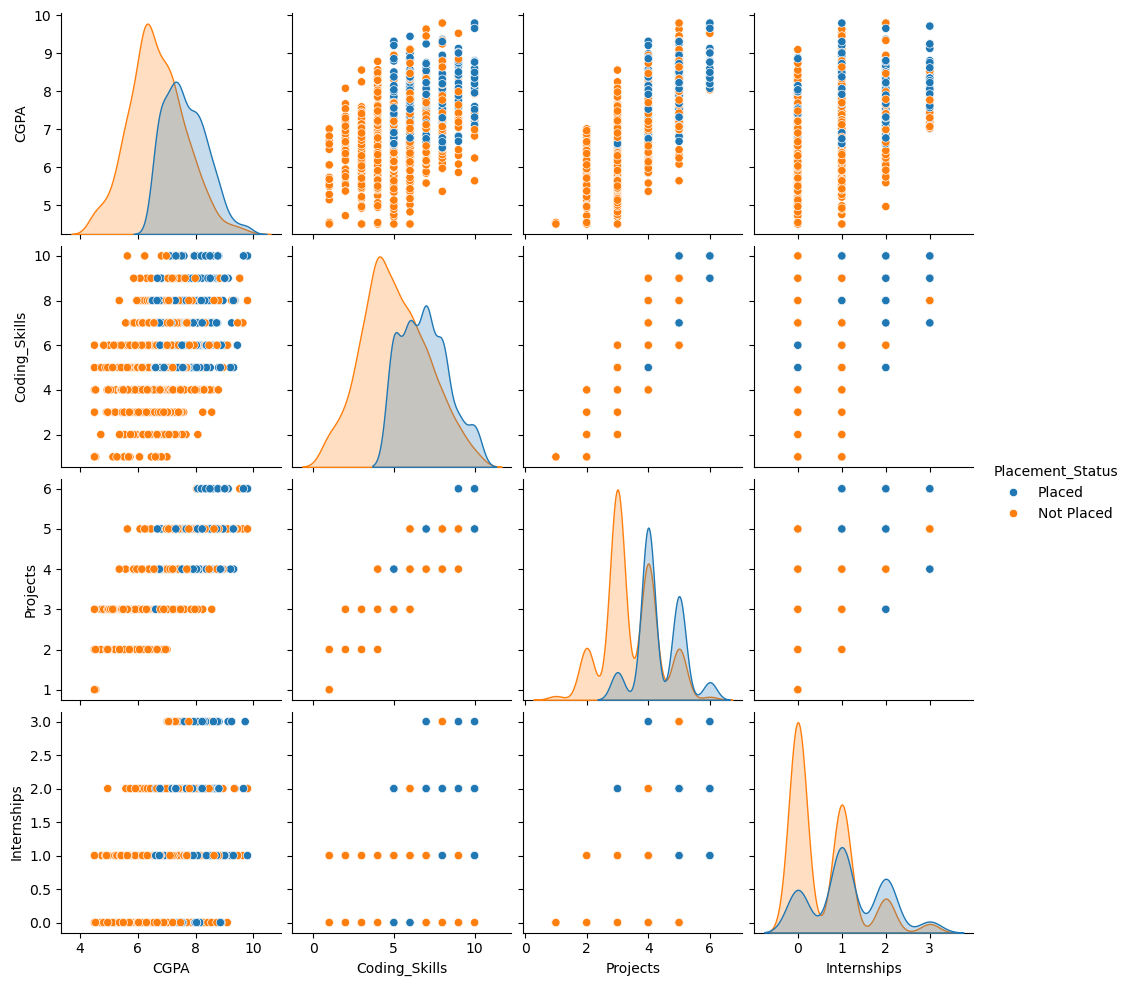

In [26]:
sample_df = df.sample(1000, random_state=42)

sns.pairplot(
    sample_df,
    vars=['CGPA','Coding_Skills','Projects','Internships'],
    hue='Placement_Status'
)

plt.show()

In [27]:
import pandas as pd

df = pd.read_excel("C:/Users/My/Downloads/datasheet_assignmet 3.xlsx")

In [28]:
print(df.head())

   Unnamed: 0  Age  Gender  Degree Branch  CGPA  Internships  Projects  \
0         NaN   22  Female  B.Tech    ECE  6.29            0         3   
1         NaN   20  Female     BCA    ECE  6.05            1         4   
2         NaN   22    Male     MCA     ME  7.22            1         4   
3         NaN   22    Male     MCA     ME  7.78            2         4   
4         NaN   20  Female  B.Tech     ME  7.63            1         4   

   Coding_Skills  Communication_Skills  Aptitude_Test_Score  \
0              4                     6                   51   
1              6                     8                   59   
2              6                     6                   58   
3              6                     6                   90   
4              6                     5                   79   

   Soft_Skills_Rating  Certifications  Backlogs Placement_Status  
0                   5               1         3       Not Placed  
1                   8               2     

In [29]:
X = df.drop("Placement_Status", axis=1)
y = df["Placement_Status"]

In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
le = LabelEncoder()

In [32]:
categorical_columns = X.select_dtypes(include='object').columns

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

In [33]:
y = le.fit_transform(y)

In [34]:
X.head()

,Unnamed: 0,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
0,NaN,22,0,1,2,6.29,0,3,4,6,51,5,1,3
1,NaN,20,0,2,2,6.05,1,4,6,8,59,8,2,1
2,NaN,22,1,3,4,7.22,1,4,6,6,58,6,2,2
3,NaN,22,1,3,4,7.78,2,4,6,6,90,4,2,0
4,NaN,20,0,1,4,7.63,1,4,6,5,79,6,2,0


In [35]:
print(y[:10])

[0 0 0 1 1 1 0 0 0 0]


### Split the Dataset

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (36000, 14)
Testing Data  : (9000, 14)


### Feature Scaling

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

In [41]:
print(X.isnull().sum())

Unnamed: 0              45000
Age                         0
Gender                      0
Degree                      0
Branch                      0
CGPA                        0
Internships                 0
Projects                    0
Coding_Skills               0
Communication_Skills        0
Aptitude_Test_Score         0
Soft_Skills_Rating          0
Certifications              0
Backlogs                    0
dtype: int64


In [42]:
print(X_train.shape)

(36000, 14)


In [43]:
print(X.dtypes)

Unnamed: 0              float64
Age                       int64
Gender                    int64
Degree                    int64
Branch                    int64
CGPA                    float64
Internships               int64
Projects                  int64
Coding_Skills             int64
Communication_Skills      int64
Aptitude_Test_Score       int64
Soft_Skills_Rating        int64
Certifications            int64
Backlogs                  int64
dtype: object


In [44]:
import numpy as np

print(np.isinf(X).sum())

Unnamed: 0              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
dtype: int64


In [45]:
X = X.drop("Unnamed: 0", axis=1)

In [46]:
X.shape

(45000, 13)

### Section 5  Data Preprocessing

In [47]:
# Remove unwanted column
df = df.drop("Unnamed: 0", axis=1)

In [87]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = X.select_dtypes(include="object").columns

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

y = le.fit_transform(y)

In [95]:
# Remove unwanted column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Create X and y again
X = df.drop("Placement_Status", axis=1)
y = df["Placement_Status"]

In [104]:
from sklearn.preprocessing import LabelEncoder

# Create X and y
X = df.drop("Placement_Status", axis=1)
y = df["Placement_Status"]

# Create a LabelEncoder
le = LabelEncoder()

# Convert text columns into numbers
for col in ["Gender", "Degree", "Branch"]:
    X[col] = le.fit_transform(X[col])

# Convert target into numbers
y = le.fit_transform(y)

In [105]:
print(X.dtypes)

Age                       int64
Gender                    int64
Degree                    int64
Branch                    int64
CGPA                    float64
Internships               int64
Projects                  int64
Coding_Skills             int64
Communication_Skills      int64
Aptitude_Test_Score       int64
Soft_Skills_Rating        int64
Certifications            int64
Backlogs                  int64
dtype: object


In [96]:
print(X.columns)
print(X.shape)

Index(['Age', 'Gender', 'Degree', 'Branch', 'CGPA', 'Internships', 'Projects',
       'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score',
       'Soft_Skills_Rating', 'Certifications', 'Backlogs'],
      dtype='object')
(45000, 13)


In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [102]:
print(X.dtypes)

Age                       int64
Gender                   object
Degree                   object
Branch                   object
CGPA                    float64
Internships               int64
Projects                  int64
Coding_Skills             int64
Communication_Skills      int64
Aptitude_Test_Score       int64
Soft_Skills_Rating        int64
Certifications            int64
Backlogs                  int64
dtype: object


In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [116]:
print(X_train.shape)

import numpy as np

print("NaN values:", np.isnan(X_train).sum())
print("Infinite values:", np.isinf(X_train).sum())

(36000, 13)
NaN values: 0
Infinite values: 0


In [109]:
print(type(X_train))

<class 'numpy.ndarray'>


In [117]:
print(X_train.dtypes)

AttributeError: 'numpy.ndarray' object has no attribute 'dtypes'

In [111]:
print(type(X_train))
print(X_train.dtype)

<class 'numpy.ndarray'>
float64


In [112]:
import numpy as np

print("NaN:", np.isnan(X_train).sum())
print("Inf:", np.isinf(X_train).sum())

NaN: 0
Inf: 0


In [113]:
print(X_train[:5])

[[-5.03870580e-01  1.00378494e+00  4.50705430e-01  1.41142900e+00
   1.50584854e+00 -9.13439953e-01  2.88774789e-01  1.56039423e-01
  -3.32174986e-01  6.17260908e-01 -4.07170942e-01  3.06024970e-01
  -9.11609812e-01]
 [ 9.99888198e-01 -9.96229331e-01  1.34353520e+00 -1.41504060e+00
   2.29107210e-01  2.63875344e+00  2.88774789e-01  6.56656053e-01
   9.87434315e-01  9.04513023e-01 -4.07170942e-01  3.06024970e-01
   1.14846070e+00]
 [-1.50637643e+00  1.00378494e+00  1.34353520e+00  1.41142900e+00
   3.59797267e-01  2.70624511e-01  2.88774789e-01  1.56039423e-01
   3.27629665e-01  2.58195765e-01 -2.02596210e+00  3.06024970e-01
  -9.11609812e-01]
 [ 1.50114112e+00  1.00378494e+00 -1.33495412e+00 -7.08423198e-01
   1.47568929e+00 -9.13439953e-01  2.88774789e-01  1.56039423e-01
  -2.31158894e+00  9.04513023e-01 -4.07170942e-01  3.06024970e-01
  -9.11609812e-01]
 [ 1.50114112e+00  1.00378494e+00  1.34353520e+00 -1.80580002e-03
   5.50805812e-01  1.45468898e+00  2.88774789e-01  6.56656053e-01


In [114]:
import numpy as np

print("Shape:", X_train.shape)
print("NaN values:", np.isnan(X_train).sum())
print("Infinite values:", np.isinf(X_train).sum())

Shape: (36000, 13)
NaN values: 0
Infinite values: 0


In [115]:
print(np.where(np.isnan(X_train)))

(array([], dtype=int64), array([], dtype=int64))


In [108]:
print(type(X_train))
print(X_train.shape)
print(X_train.isnull().sum())

<class 'numpy.ndarray'>
(36000, 13)


AttributeError: 'numpy.ndarray' object has no attribute 'isnull'

In [93]:
print(df.columns)

Index(['Age', 'Gender', 'Degree', 'Branch', 'CGPA', 'Internships', 'Projects',
       'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score',
       'Soft_Skills_Rating', 'Certifications', 'Backlogs', 'Placement_Status'],
      dtype='object')


In [90]:
print(X.isnull().sum())

Unnamed: 0              45000
Age                         0
Gender                      0
Degree                      0
Branch                      0
CGPA                        0
Internships                 0
Projects                    0
Coding_Skills               0
Communication_Skills        0
Aptitude_Test_Score         0
Soft_Skills_Rating          0
Certifications              0
Backlogs                    0
dtype: int64


### Train Logistic Regression

In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
lr_model = LogisticRegression(random_state=42)

In [54]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Predictions

In [55]:
y_pred_lr = lr_model.predict(X_test)

### Check Accuracy

In [56]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8651111111111112


In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89      5738
           1       0.82      0.81      0.81      3262

    accuracy                           0.87      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.86      0.87      0.86      9000



### Section 6 First Machine Learning Model

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[5160  578]
 [ 636 2626]]


### Plot the Confusion Matrix

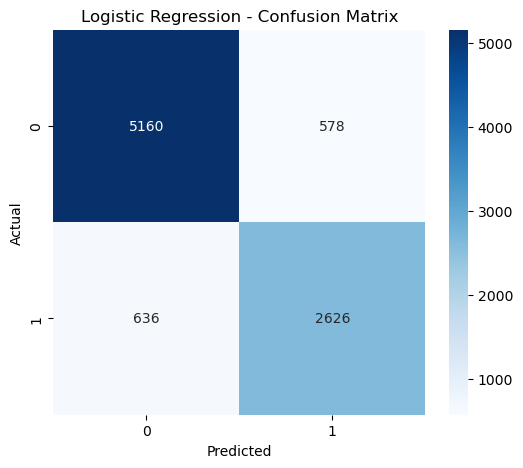

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### ROC Curve

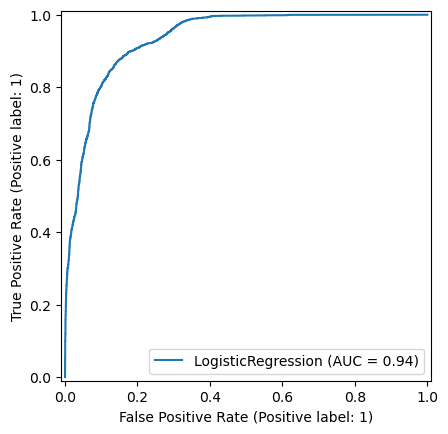

In [60]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr_model, X_test, y_test)

plt.show()

### Feature Importance

In [61]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

feature_importance

,Feature,Coefficient
8,Communication_Skills,1.635754
11,Certifications,0.943985
4,CGPA,0.374331
7,Coding_Skills,0.319872
6,Projects,0.300890
9,Aptitude_Test_Score,0.175176
5,Internships,0.103077
3,Branch,0.080789
0,Age,0.018022
2,Degree,0.000417


### Coefficients

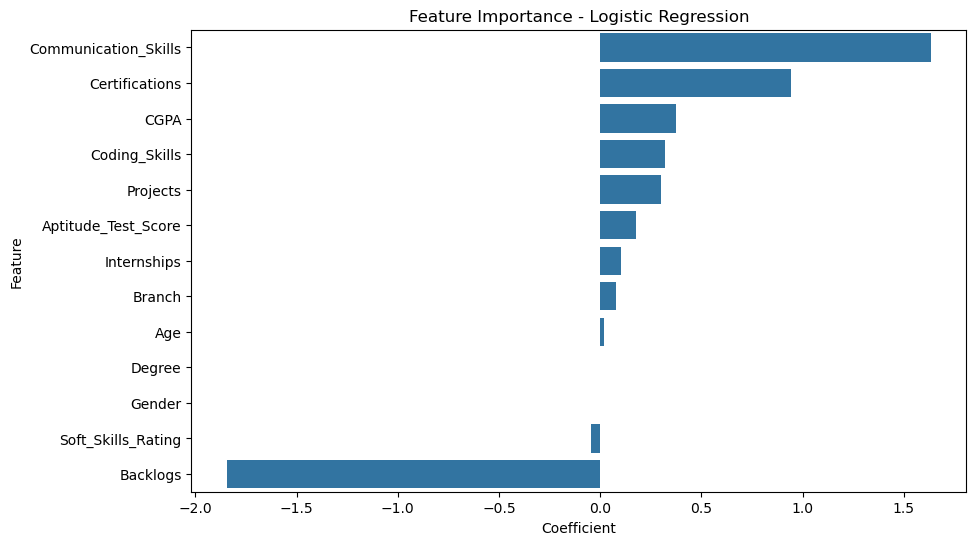

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Coefficient',
    y='Feature'
)

plt.title("Feature Importance - Logistic Regression")

plt.show()

### Section 7 - Model Training and Comparison

In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_excel("C:/Users/My/Downloads/datasheet_assignmet 3.xlsx")

In [65]:
df.head()

,Unnamed: 0,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,NaN,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,NaN,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,NaN,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,NaN,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,NaN,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [66]:
X = df.drop("Placement_Status", axis=1)

y = df["Placement_Status"].map({
    "Not Placed": 0,
    "Placed": 1
})

In [67]:
print(type(X_train))
print(type(y_train))

print(X_train.shape)
print(y_train.shape)

print(y_train.head())


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(36000, 13)
(36000,)


AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
import os
import joblib

# create folder if it doesn't exist
os.makedirs("model", exist_ok=True)

joblib.dump(model, "model/best_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")

print("Saved successfully")

#### Step 7.1 – Import Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

#### Step 7.2 – Create All Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

#### Step 7.3 – Train Every Model

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

In [ ]:
print(X.dtypes)

In [ ]:
print(X.isnull().sum())

In [ ]:
print(X.select_dtypes(include='object').columns)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = X.select_dtypes(include='object').columns

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

In [ ]:
print(X.select_dtypes(include='object').columns)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print(X.isnull().sum())

In [ ]:
print(X.columns)

In [ ]:
import numpy as np

print(np.isinf(X.select_dtypes(include=[np.number])).sum())

In [ ]:
print(X.columns)

In [ ]:
X = X.drop("Unnamed: 0", axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results.append([name, accuracy])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results.append([name, accuracy])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
results = []

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, predictions)

    # Store the results
    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

print("All models trained successfully!")

In [ ]:
print(results)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(models.keys())

### Section 7.4

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

### Section 7.5

In [ ]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

### Section 7.6

In [ ]:
best_model = results_df.iloc[0]

print("="*50)
print("BEST MACHINE LEARNING MODEL")
print("="*50)
print(f"Model    : {best_model['Model']}")
print(f"Accuracy : {best_model['Accuracy']:.4f}")

### Section 7.7

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Accuracy")
plt.ylabel("Models")

plt.show()

 ### Section 7.8

In [ ]:
results_df.to_csv("Model_Comparison.csv", index=False)

print("Model comparison table saved successfully!")

### Section 8 – Save the Best Model

import joblib

In [ ]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

In [ ]:
best_model = models[best_model_name]

In [ ]:
joblib.dump(best_model, "best_model.pkl")

print("Best model saved successfully!")

In [ ]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

In [ ]:
import os

print(os.listdir())

### Section 9 – Model Evaluation

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.title("ROC Curve")

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "model.pkl")
print("Model Saved Successfully!")

In [ ]:
print(X_train.shape)
print(X_train[:5])

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

In [ ]:
print(X.columns)


In [ ]:
print(y.value_counts())

In [ ]:
sample = X_test.iloc[[0]]

print("Prediction:", model.predict(sample))
print("Actual:", y_test.iloc[0])


In [ ]:
print(type(best_model))

In [118]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [119]:
y_pred = model.predict(X_test)

In [120]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8651111111111112
[[5160  578]
 [ 636 2626]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      5738
           1       0.82      0.81      0.81      3262

    accuracy                           0.87      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.86      0.87      0.86      9000



In [121]:
import joblib

joblib.dump(model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
